# Study 844 — Madden-Cover-Curse 🎮

*For the curious.* The gaming **"Madden curse"** says the athlete on the box gets hurt the next season. We're not a sports desk — we test the *finance* version: when the new **Madden** or **NBA 2K** ships, does the **publisher's stock** move? EA makes *Madden*; Take-Two (TTWO) makes *NBA 2K*. We put 20 annual launches (2015→2024) on the stand and asked two plain questions: **does the publisher rally into the launch?** and **does it move after?** The answer is a quiet double bust.

## The claim

A new *Madden* or *NBA 2K* is a scheduled, heavily-marketed, once-a-year ship — the retail 'buy the hype' reflex says load up on the publisher into launch day. The catch that kills it before we start: it's a *known* date, marketed months ahead, and one sports title is a small slice of a giant multi-franchise publisher (EA also ships FC and Apex; Take-Two also ships GTA). We measure the publisher's **abnormal** return (publisher − SPY, total-return) so we're not just measuring the market — each launch anchored to *its own* publisher.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from madden_curse import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching EA + TTWO + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} launches resolved")


panel loaded; 20 of 20 launches resolved


## The launch calendar we test (hardcoded from Wikipedia / press releases)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['launch', 'publisher', 'title', 'cover_athlete'])

,launch,publisher,title,cover_athlete
0,2015-08-25,EA,Madden NFL 16,Odell Beckham Jr.
1,2016-08-23,EA,Madden NFL 17,Rob Gronkowski
2,2017-08-25,EA,Madden NFL 18,Tom Brady
3,2018-08-10,EA,Madden NFL 19,Antonio Brown
4,2019-08-02,EA,Madden NFL 20,Patrick Mahomes
5,2020-08-28,EA,Madden NFL 21,Lamar Jackson
6,2021-08-20,EA,Madden NFL 22,Tom Brady & Patrick Mahomes
7,2022-08-19,EA,Madden NFL 23,John Madden
8,2023-08-18,EA,Madden NFL 24,Josh Allen
9,2024-08-16,EA,Madden NFL 25,Christian McCaffrey


## The picture: mean cumulative abnormal return around the launch

Offset 0 is the launch. Left of zero is the *run-up* (the supposed hype rally); right of zero is the *drift* window (ride it or sell the news).

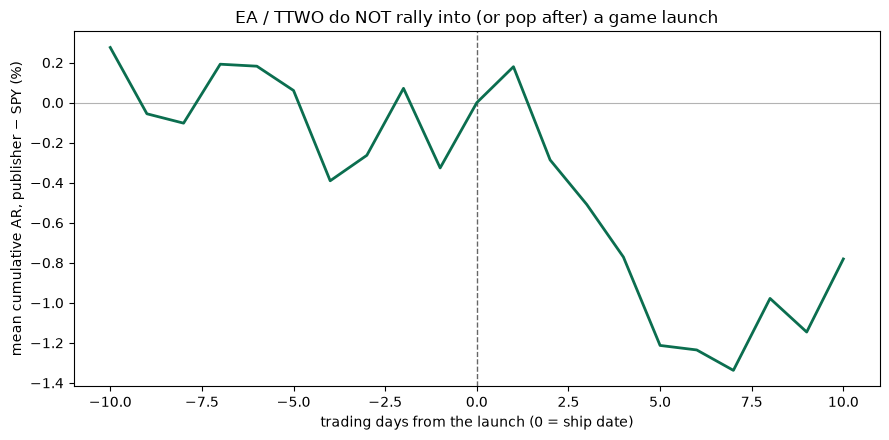

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#0b6e4f', lw=2)
ax.set_xlabel('trading days from the launch (0 = ship date)')
ax.set_ylabel('mean cumulative AR, publisher − SPY (%)')
ax.set_title('EA / TTWO do NOT rally into (or pop after) a game launch')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 1-week run-up | +0.05% | +0.07 | 10/20 |
| 2-week run-up | -0.17% | -0.20 | 10/20 |
| 1-week drift | -1.21% | -1.89 | 8/20 |
| 2-week drift | -0.78% | -0.91 | 9/20 |

The bullish folklore just **isn't there**: the run-up is a clean zero (+0.05% / -0.17%, |*t*| < 0.25, hit 10/20 — an exact coin flip). And after the launch the publisher, if anything, drifts *down* (-1.21% in the first week) — the **wrong way** for a 'buy the hype' trade, and not significant anyway (*t* = -1.89, |*t*| < 2).

In [4]:
rows = [('1wk run-up','pre_s'),('2wk run-up','pre_l'),('1wk drift','post_s'),('2wk drift','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<11s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

1wk run-up  n=20  mean=+0.048%  t=+0.072  hit 10/20
2wk run-up  n=20  mean=-0.168%  t=-0.197  hit 10/20
1wk drift   n=20  mean=-1.213%  t=-1.889  hit 8/20
2wk drift   n=20  mean=-0.781%  t=-0.906  hit 9/20


## So what?

The finance version of the *Madden curse* is folklore: EA and TTWO don't rally into a launch (a clean zero) and don't reliably pop after (a faint, insignificant *dip* if anything — the wrong way for 'buy the hype'). On top of the missing signal, the date is public months ahead and a single sports title is a small slice of a huge publisher's revenue. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the splits, the jackknife, the costed leg and the synthetic control.